In [ ]:
"""! @brief Simple/Complex Text Classification with Logistic Regression"""
# @file TP3.ipynb
#
# @mainpage TP3
#
# @section description_main Description
# This project focuses on the design and implementation of a Multilayer Perceptron (MLP) for classification tasks. The MLP is initially trained and evaluated
# on a small dataset to validate its architecture and learning process. Subsequently, the model is optimized using Optuna and trained on the ACRIMA dataset.
# In addition, the project explores the use of AlexNet, which is also trained and evaluated on the ACRIMA dataset. Finally, a comparative analysis is conducted
# between the optimized MLP and AlexNet to assess their classification performance and determine the strengths and limitations of each approach.
#
# @section dataset_main Dataset
# - ACRIMA (https://www.kaggle.com/datasets/toaharahmanratul/acrima-dataset)
#
# @section libraries_main Libraries
# - torch (https://docs.pytorch.org/docs/stable/index.html)
#   - Access to tensor and all its operations
# - matplotlib.pyplot (https://matplotlib.org/stable/index.html)
#   - Access to plot, contour and other visual options
# - pandas (https://pandas.pydata.org/docs/)
#   - Used to generate tables
# - sklearn (https://scikit-learn.org/stable/)
#   - Used to generate the dataset
# - dataclass (https://docs.python.org/es/3.9/library/dataclasses.html)
#   - Used to access special features of the python classes
# - random (https://docs.python.org/3/library/random.html)
#   - Used to shuffle the dataset
# - re (https://docs.python.org/es/3/library/re.html)
#   - Used to create regular expressions
# - sys (https://docs.python.org/es/3/library/sys.html)
#   - Used to find where the script is running
# - os (https://docs.python.org/es/3.10/library/os.html)
#   - Used to install dependencies
# - optuna (https://optuna.readthedocs.io/en/stable/index.html)
#   - Used to optimize hyperparameters automatically
# - numpy (https://numpy.org/doc/)
#   - Numerical computing library for array operations
# - math (https://docs.python.org/3/library/math.html)
#   - Access to sqrt
# - PIL (https://pypi.org/project/pillow/)
#   - Used for Image reading
# - torchvision (https://pypi.org/project/torchvision/)
#   - Used for dataset treatment
#
# @section imports_main Imports
# - Util (https://github.com/Luco1421/TPs_IA/blob/master/TP3/Util.py)
#   - Used for general utilities
#
# @section authors_main Authors
# - Alejandro Cerdas
# - Kener Castillo
# - Pablo Perez

In [2]:
# @brief Installs and updates the required Python packages.
import sys

# Updates pip to the latest available version.
!{sys.executable} -m pip install -U pip

# Installs or updates the PyTorch package with CUDA 12.8 support.
# Uncomment this line if GPU acceleration is required.
# !{sys.executable} -m pip install -U torch --index-url https://download.pytorch.org/whl/cu128

# Installs the Optuna framework for hyperparameter optimization.
!{sys.executable} -m pip install optuna

In [3]:
# @brief Imports required libraries and modules.
import pandas as pd
import optuna
import torch
import Util
import numpy as np
import math
import os

from Util import DatasetGenerator, Visualization, Table
from dataclasses import dataclass
from torch.nn.functional import mse_loss
import torch.nn as nn
from PIL import Image
from torch.utils.data import random_split, DataLoader
from torchvision.datasets import ImageFolder
import torch.optim as optim
from torchvision import datasets, transforms, models

C:\Users\Luco1421\Desktop\U\ia\TPs\TP3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# @brief Global configuration settings.

# Device used for tensor computations (CPU or GPU).
DEVICE = Util.DEVICE

# Default tensor data type used throughout the project.
TYPE = Util.TYPE

# Configure tensor printing to display up to 10 decimal places.
torch.set_printoptions(precision=10)

# Global instance of the visualization utility class used for plotting results, metrics, and model performance.
visualization = Visualization()

In [5]:
# @brief Xavier-Glorot weight initialization.

def xavier_glorot_init(fan_in, fan_out):
    """! Computes the Xavier-Glorot initialization limit.

    Calculates the initialization range used to generate
    uniformly distributed weights for a neural network layer.

    @param fan_in Number of input neurons.
    @param fan_out Number of output neurons.

    @return Xavier-Glorot initialization limit.
    """
    return (6 / (fan_in + fan_out)) ** 0.5

class MultilayerPerceptron:
    """! Multilayer Perceptron implementation.

    Implements a feedforward neural network with a single hidden
    layer trained using backpropagation and gradient descent with
    momentum.
    """
    def __init__(self, neurons_per_layer : list [int], alpha : float, gamma : float, max_weights : float):
        """! Initializes the Multilayer Perceptron.

        Creates the network architecture, initializes weights
        using Xavier-Glorot initialization, and allocates all
        tensors required during training.

        @param neurons_per_layer List containing the number of
                                 neurons in the input, hidden,
                                 and output layers.
        @param alpha Learning rate.
        @param gamma Momentum coefficient.
        @param max_weights Maximum absolute value allowed for
                           weights and biases.

        @return An instance of the MultilayerPerceptron class.
        """

        self.d, self.m, self.k = neurons_per_layer

        self.alpha = alpha
        self.gamma = gamma
        self.max_weights = max_weights

        self.xavier_glorot_o = xavier_glorot_init(self.d, self.m)
        self.xavier_glorot_s = xavier_glorot_init(self.m, self.k)

        self.Wo = torch.empty(self.d, self.m, dtype=TYPE, device=DEVICE).uniform_(-self.xavier_glorot_o, self.xavier_glorot_o)
        self.Ws = torch.empty(self.m, self.k, dtype=TYPE, device=DEVICE).uniform_(-self.xavier_glorot_s, self.xavier_glorot_s)

        self.Bo = torch.zeros(1, self.m, dtype=TYPE, device=DEVICE)
        self.Bs = torch.zeros(1, self.k, dtype=TYPE, device=DEVICE)

        self.delta_Wo = torch.zeros(1, self.m, dtype=TYPE, device=DEVICE)
        self.delta_Ws = torch.zeros(1, self.k, dtype=TYPE, device=DEVICE)

        self.Po = torch.zeros(1, self.m, dtype=TYPE, device=DEVICE)
        self.Yo = torch.zeros(1, self.m, dtype=TYPE, device=DEVICE)
        self.Ps = torch.zeros(1, self.k, dtype=TYPE, device=DEVICE)
        self.Ys = torch.zeros(1, self.k, dtype=TYPE, device=DEVICE)

        self.activation = nn.Sigmoid()

        self.V_Wo = torch.zeros(self.d, self.m, dtype=TYPE, device=DEVICE)
        self.V_Ws = torch.zeros(self.m, self.k, dtype=TYPE, device=DEVICE)
        self.V_Bo = torch.zeros(self.m, dtype=TYPE, device=DEVICE)
        self.V_Bs = torch.zeros(self.k, dtype=TYPE, device=DEVICE)

    def forward(self, X : torch.Tensor):
        """! Performs forward propagation.

        Computes the activations of the hidden and output layers
        for the provided input samples.

        @param X Input samples.
        """
        self.Po = (X @ self.Wo) + self.Bo
        self.Yo = self.activation(self.Po)
        self.Ps = (self.Yo @ self.Ws) + self.Bs
        self.Ys = self.activation(self.Ps)

    def backpropagate_deltas(self, T: torch.Tensor):
        """! Computes the backpropagation deltas.

        Calculates the error terms for the output and hidden
        layers using the backpropagation algorithm.

        @param T Target outputs.
        """
        self.delta_Ws = (self.Ys - T) * (self.Ys * (1 - self.Ys))
        self.delta_Wo = (self.delta_Ws  @ self.Ws.T) * self.Yo * (1 - self.Yo)

    def update_weights(self, X: torch.Tensor):
        """! Updates network weights and biases.

        Applies gradient descent with momentum to update the
        weights and biases of the hidden and output layers.
        Updated values are constrained using weight clipping.

        @param X Input batch used to compute average gradients.
        """
        n = X.shape[0]
        self.V_Wo = self.V_Wo * self.gamma + self.alpha * (1 - self.gamma) * (X.T @ self.delta_Wo) / n
        self.Wo = (self.Wo - self.V_Wo).clamp(-self.max_weights, self.max_weights)

        self.V_Bo = self.V_Bo * self.gamma + self.alpha * (1 - self.gamma) * self.delta_Wo.sum(dim=0) / n
        self.Bo = (self.Bo - self.V_Bo).clamp(-self.max_weights, self.max_weights)

        self.V_Ws = self.V_Ws * self.gamma + self.alpha * (1 - self.gamma) * (self.Yo.T @ self.delta_Ws) / n
        self.Ws = (self.Ws - self.V_Ws).clamp(-self.max_weights, self.max_weights)

        self.V_Bs = self.V_Bs * self.gamma + self.alpha * (1 - self.gamma) * self.delta_Ws.sum(dim=0) / n
        self.Bs = (self.Bs - self.V_Bs).clamp(-self.max_weights, self.max_weights)

    def get_error(self, T: torch.Tensor):
        """! Computes the network error.

        Calculates the Mean Squared Error (MSE) between the
        network predictions and the target values.

        @param T Target outputs.

        @return Mean Squared Error value.
        """
        return mse_loss(self.Ys, T)

    def get_accuracy(self, T: torch.Tensor):
        """! Computes classification accuracy.

        Calculates the prediction accuracy for binary or
        multiclass classification problems.

        @param T Target outputs.

        @return Classification accuracy.
        """
        if self.k == 1:
            return (self.Ys.round() == T).float().mean()
        return (torch.argmax(self.Ys, dim=1) == torch.argmax(T, dim=1)).float().mean()

    def train_mlp(self, num_epochs: int, X : torch.Tensor, T : torch.Tensor, alpha : float | None = None, gamma : float | None = None, epsilon : float | None = None):
        """! Trains the Multilayer Perceptron.

        Executes the training loop for a specified number of
        epochs. During training, forward propagation,
        backpropagation, and weight updates are performed.
        Optionally supports early stopping based on an error
        threshold.

        @param num_epochs Number of training epochs.
        @param X Training inputs.
        @param T Training targets.
        @param alpha Optional learning rate.
        @param gamma Optional momentum coefficient.
        @param epsilon Optional early stopping threshold.

        @return Lists containing the error and accuracy history.
        """
        if alpha is not None:
            self.alpha = alpha
        if gamma is not None:
            self.gamma = gamma
        history_error = []
        history_accuracy = []
        for _ in range(num_epochs):
            self.forward(X)
            history_error.append(self.get_error(T))
            history_accuracy.append(self.get_accuracy(T))

            self.backpropagate_deltas(T)
            self.update_weights(X)
            if epsilon is not None and history_error[-1] < epsilon:
                break
        self.forward(X)
        history_error.append(self.get_error(T))
        history_accuracy.append(self.get_accuracy(T))

        return [t.item() for t in history_error], [t.item() for t in history_accuracy]

    def evaluate_batches(self, test_loader) :
        """! Evaluates the model on batches.

        Computes the average error and accuracy over all batches
        contained in the provided data loader.

        @param test_loader DataLoader containing evaluation data.

        @return Mean error and mean accuracy.
        """
        error = []
        accuracy = []
        for X_batch, T_batch in test_loader:
            X_batch = X_batch.to(DEVICE)
            T_batch = T_batch.view(-1, 1).to(DEVICE)
            self.forward(X_batch)
            error.append(self.get_error(T_batch))
            accuracy.append(self.get_accuracy(T_batch))
        return np.mean([t.item() for t in error]).item(), np.mean([t.item() for t in accuracy]).item()

    def train_batches(self, num_epochs: int, train_loader, alpha : float | None = None, gamma : float | None = None):
        """! Trains the model using mini-batches.

        Performs training using batches provided by a DataLoader.
        The network parameters are updated after each batch.

        @param num_epochs Number of training epochs.
        @param train_loader DataLoader containing training data.
        @param alpha Optional learning rate.
        @param gamma Optional momentum coefficient.

        @return History of training error values.
        """
        if alpha is not None:
            self.alpha = alpha
        if gamma is not None:
            self.gamma = gamma
        history_error = []
        for _ in range(num_epochs):
            error = []
            for X_batch, T_batch in train_loader:
                X_batch = X_batch.to(DEVICE)
                T_batch = T_batch.view(-1, 1).to(DEVICE)
                self.forward(X_batch)
                self.backpropagate_deltas(T_batch)
                self.update_weights(X_batch)
                error.append(self.get_error(T_batch))
            history_error.append(np.mean([t.item() for t in error]))
        return history_error

#

In [6]:
@dataclass
class TestData:
    X = torch.tensor ([
        [1.0, 2.0, 3.0],
        [5.0, 6.0, 7.0],
        [8.0, 9.0, 10.0]
    ], dtype=TYPE, device=DEVICE)
    T = torch.tensor ([
        [0],
        [1],
        [0]
    ], dtype=TYPE, device=DEVICE)
    Wo = torch.tensor ([
        [0.1, 0.2, 0.3, 0.4],
        [0.5, 0.6, 0.7, 0.8],
        [0.9, 1.0, 1.1, 1.2]
    ], dtype=TYPE, device=DEVICE)
    Ws = torch.tensor ([
        [2.0],
        [2.1],
        [2.2],
        [2.3]
    ], dtype=TYPE, device=DEVICE)
    Bs = torch.tensor (
        [0.5],
    dtype=TYPE, device=DEVICE)
    Bo = torch.tensor (
            [3.0, 3.1, 3.2, 3.3],
    dtype=TYPE, device=DEVICE)
    alpha = 0.1
    gamma = 0.9
    max_value = 1e3
    epsilon = 1e-5

## Test Forward

In [87]:
def forward_test():
    expected_Ys = torch.tensor([
        [0.9999],
        [0.9999],
        [0.9999]
    ],dtype=TYPE, device=DEVICE)

    mlp = MultilayerPerceptron([3, 4, 1], TestData.alpha, TestData.gamma, TestData.max_value)
    mlp.Wo = TestData.Wo
    mlp.Ws = TestData.Ws
    mlp.Bs = TestData.Bs
    mlp.Bo = TestData.Bo
    mlp.forward(TestData.X)

    print(f"Ys: {mlp.Ys}")

    if torch.allclose(mlp.Ys, expected_Ys, atol=TestData.epsilon) :
        print("Test Forward OK")
    else:
        print("Test Forward FAIL")

forward_test()

Ys: tensor([[0.9998878241],
        [0.9998883009],
        [0.9998883009]], device='cuda:0')
Test Forward OK


In [97]:
def test_backpropagate_deltas():
    expected_delta_s = torch.tensor([
        [0.00011],
        [0],
        [0.00011]
    ], dtype=TYPE, device=DEVICE)

    expected_delta_o = torch.tensor([
        [0,0,0,0],
        [0,0,0,0],
        [0,0,0,0],
    ], dtype=TYPE, device=DEVICE)

    mlp = MultilayerPerceptron([3, 4, 1], TestData.alpha, TestData.gamma, TestData.max_value)
    mlp.Wo = TestData.Wo
    mlp.Ws = TestData.Ws
    mlp.Bs = TestData.Bs
    mlp.Bo = TestData.Bo
    mlp.forward(TestData.X)
    mlp.backpropagate_deltas(TestData.T)

    print(mlp.Yo)

    print(f"delta_s: {mlp.delta_Ws}")
    print(f"delta_o: {mlp.delta_Wo}")

    if torch.allclose(mlp.delta_Ws, expected_delta_s, atol=TestData.epsilon) :
        print("Test Backpropagate Deltas s OK")
    else:
        print("Test Backpropagate Deltas s FAIL")

    if torch.allclose(mlp.delta_Wo, expected_delta_o, atol=TestData.epsilon) :
        print("Test Backpropagate Deltas o OK")
    else:
        print("Test Backpropagate Deltas o FAIL")

test_backpropagate_deltas()

tensor([[0.9988874793, 0.9994471669, 0.9997254014, 0.9998636246],
        [0.9999972582, 0.9999996424, 0.9999998808, 1.0000000000],
        [1.0000000000, 1.0000000000, 1.0000000000, 1.0000000000]],
       device='cuda:0')
delta_s: tensor([[ 1.1215078121e-04],
        [-1.2475296352e-08],
        [ 1.1167414777e-04]], device='cuda:0')
delta_o: tensor([[ 2.4926251285e-07,  1.3012940769e-07,  6.7733573417e-08,
          3.5172803337e-08],
        [-6.8409687637e-14, -9.3691754252e-15, -3.2717763554e-15,
         -0.0000000000e+00],
        [ 0.0000000000e+00,  0.0000000000e+00,  0.0000000000e+00,
          0.0000000000e+00]], device='cuda:0')
Test Backpropagate Deltas s OK
Test Backpropagate Deltas o OK


In [92]:
def test_update_weights():
    expected_Wo = torch.tensor([
        [0.1, 0.2, 0.3, 0.4],
        [0.5, 0.6, 0.7, 0.8],
        [0.9, 1, 1.1, 1.2],
    ], dtype=TYPE, device=DEVICE)

    expected_Ws = torch.tensor([
        [2],
        [2.1],
        [2.2],
        [2.3]
    ], dtype=TYPE, device=DEVICE)

    expected_Bo = torch.tensor([3, 3.1, 3.2, 3.3], dtype=TYPE, device=DEVICE)

    expected_Bs = torch.tensor([0.5], dtype=TYPE, device=DEVICE)

    mlp = MultilayerPerceptron([3,4,1], TestData.alpha, TestData.gamma, TestData.max_value)
    mlp.Wo = TestData.Wo
    mlp.Ws = TestData.Ws
    mlp.Bo = TestData.Bo
    mlp.Bs = TestData.Bs
    mlp.forward(TestData.X)
    mlp.backpropagate_deltas(TestData.T)
    mlp.update_weights(TestData.X)

    print(f"Wo: {mlp.Wo}")
    print(f"Ws: {mlp.Ws}")
    print(f"Bo: {mlp.Bo}")
    print(f"Bs: {mlp.Bs}")

    if torch.allclose(mlp.Wo, expected_Wo, atol=TestData.epsilon) :
        print("Test Update Weights Wo OK")
    else:
        print("Test Update Weights Wo FAIL")

    if torch.allclose(mlp.Ws, expected_Ws, atol=TestData.epsilon) :
        print("Test Update Weights Ws OK")
    else:
        print("Test Update Weights Ws FAIL")

    if torch.allclose(mlp.Bo, expected_Bo, atol=TestData.epsilon) :
        print("Test Update Weights Bo OK")
    else :
        print("Test Update Weights Bo FAIL")

    if torch.allclose(mlp.Bs, expected_Bs, atol=TestData.epsilon) :
        print("Test Update Weights Bs OK")
    else :
        print("Test Update Weights Bs FAIL")

test_update_weights()

Wo: tensor([[0.1000000015, 0.2000000030, 0.3000000119, 0.4000000060],
        [0.5000000000, 0.6000000238, 0.6999999881, 0.8000000119],
        [0.8999999762, 1.0000000000, 1.1000000238, 1.2000000477]],
       device='cuda:0')
Ws: tensor([[1.9999992847],
        [2.0999991894],
        [2.1999993324],
        [2.2999992371]], device='cuda:0')
Bo: tensor([3.0000000000, 3.0999999046, 3.2000000477, 3.2999999523],
       device='cuda:0')
Bs: tensor([0.4999992549], device='cuda:0')
Test Update Weights Wo OK
Test Update Weights Ws OK
Test Update Weights Bo OK
Test Update Weights Bs OK


In [15]:
def test_train_mlp():
    expected_error = [0.666506, 0.666506]
    expected_accuracy = [0.33333, 0.33333]

    mlp = MultilayerPerceptron([3,4,1], TestData.alpha, TestData.gamma, TestData.max_value)
    mlp.Wo = TestData.Wo
    mlp.Ws = TestData.Ws
    mlp.Bo = TestData.Bo
    mlp.Bs = TestData.Bs
    error, accuracy = mlp.train_mlp(1, TestData.X, TestData.T, TestData.epsilon)

    print(f"Error: {error}")
    print(f"Accuracy: {accuracy}")

    if torch.allclose(torch.tensor(expected_error), torch.tensor(error), atol=TestData.epsilon) :
        print("Test Train MLP Error OK")
    else:
        print("Test Train MLP Error FAIL")

    if torch.allclose(torch.tensor(expected_accuracy), torch.tensor(accuracy), atol=TestData.epsilon) :
        print("Test Train MLP Accuracy OK")
    else:
        print("Test Train MLP Accuracy FAIL")
test_train_mlp()

Error: [0.666517436504364, 0.666517436504364]
Accuracy: [0.3333333432674408, 0.3333333432674408]
Test Train MLP Error OK
Test Train MLP Accuracy OK


# Data utils for XOR

In [21]:
@dataclass
class DataXOR:
    X = torch.tensor([
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1]
    ], dtype=TYPE, device=DEVICE)
    M = 2
    T = torch.tensor([
        [1,0],
        [0,1],
        [0,1],
        [1,0]
    ], dtype=TYPE, device=DEVICE)
    class0 = torch.tensor([
        [0,0],
        [1,1]
    ])
    class1 = torch.tensor([
        [1,0],
        [0,1]
    ])


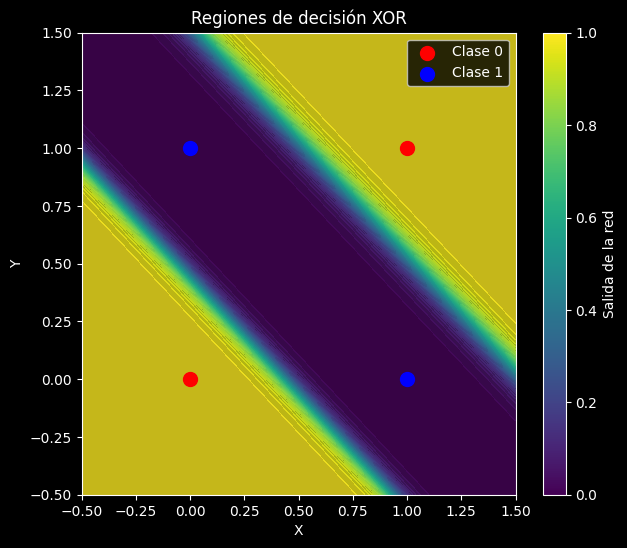

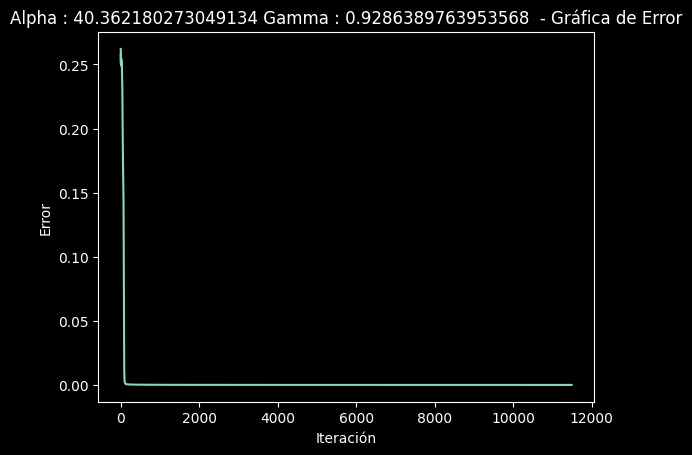

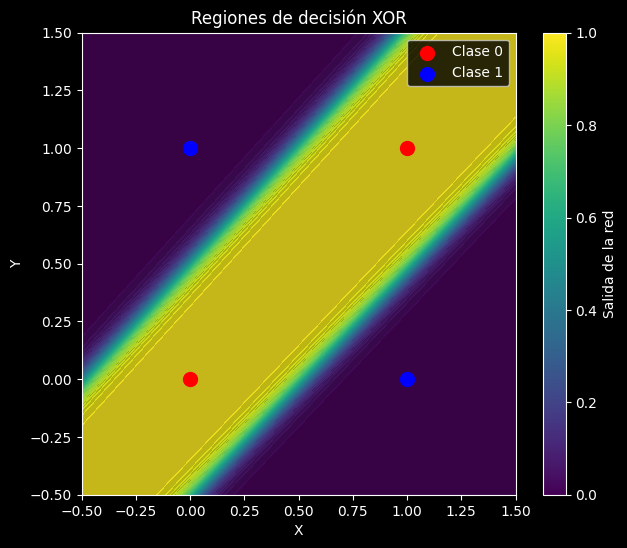

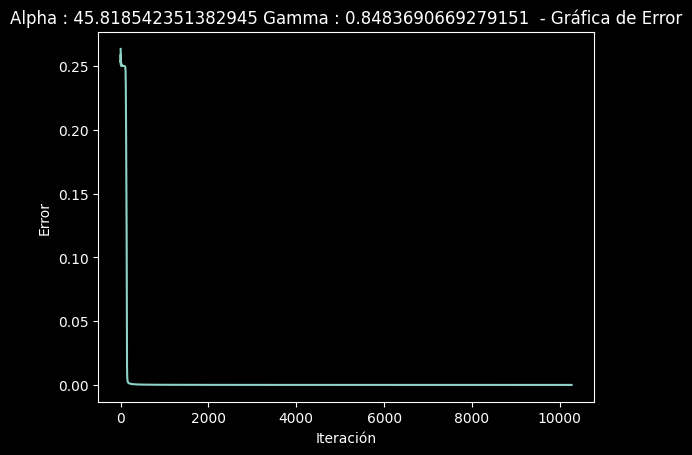

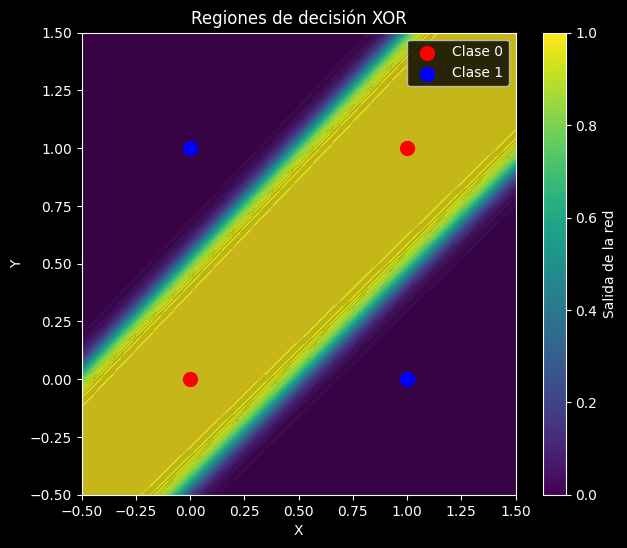

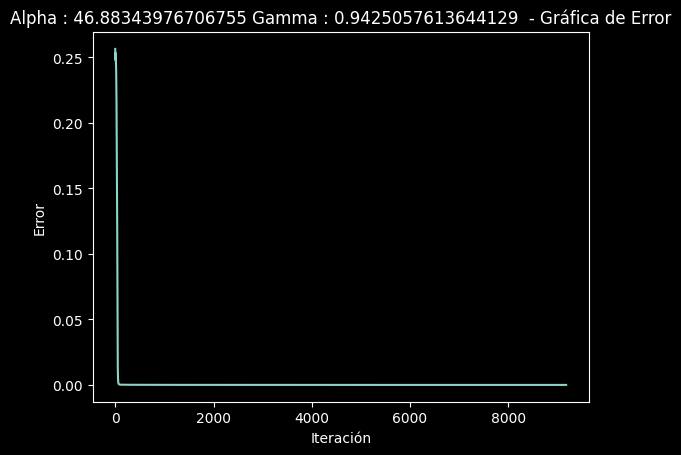

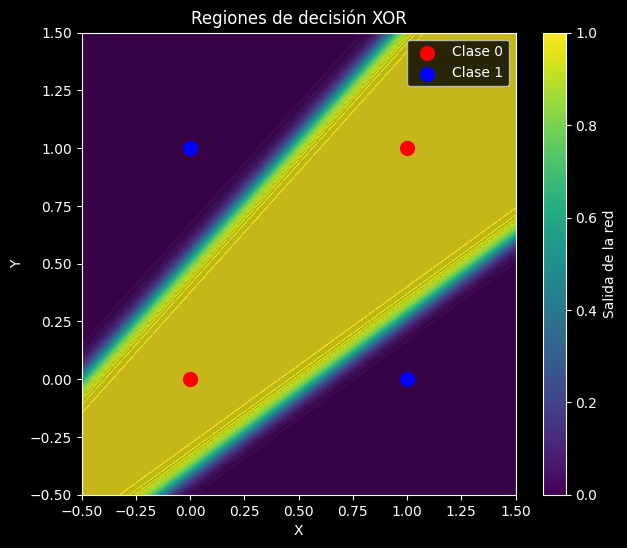

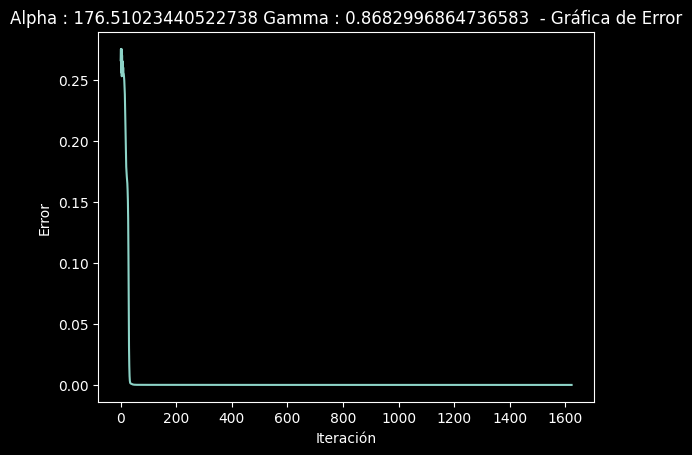

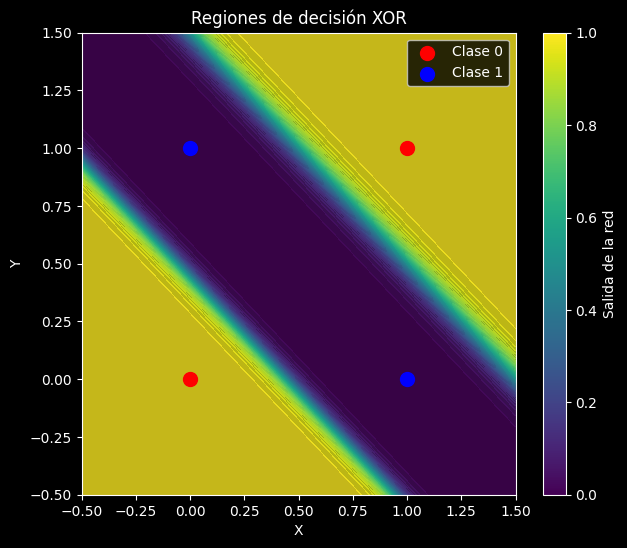

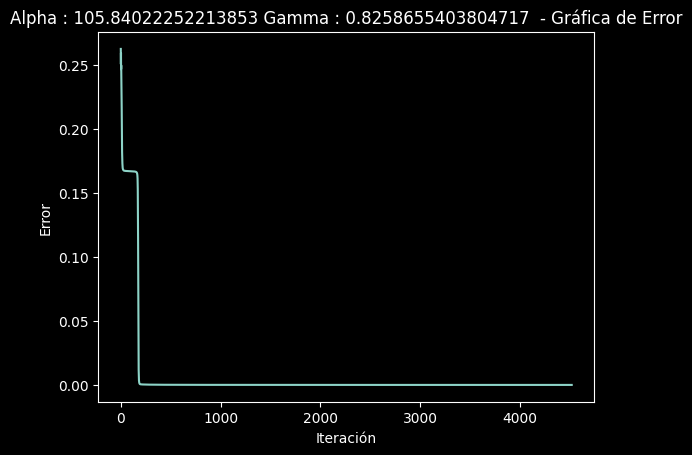

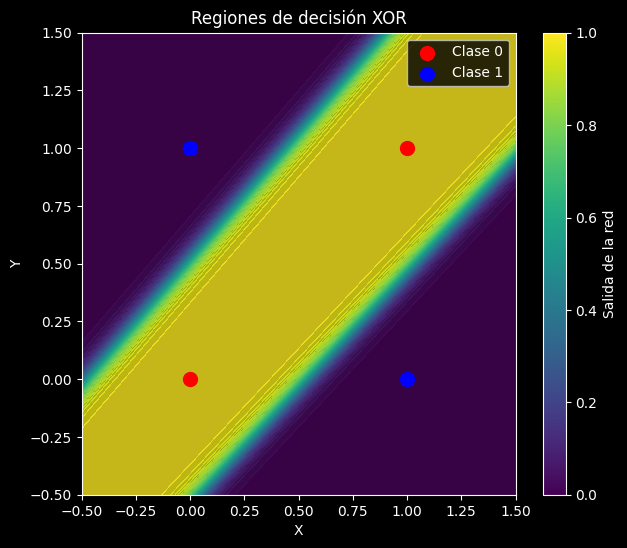

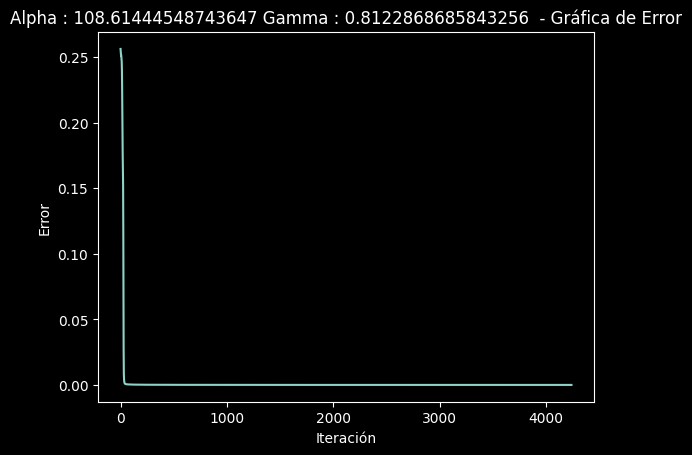

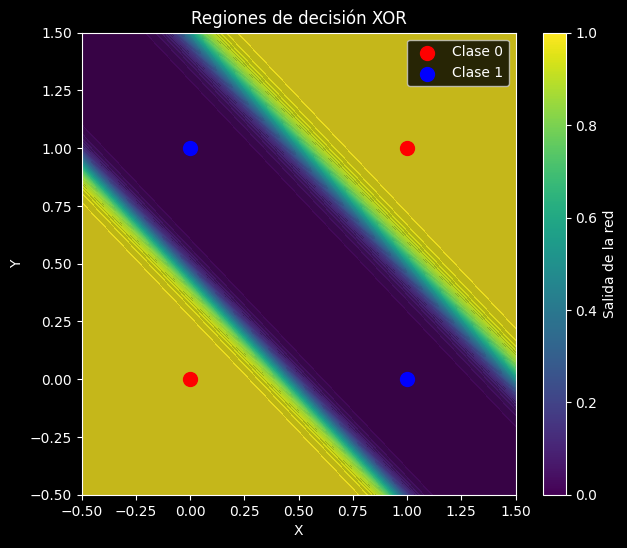

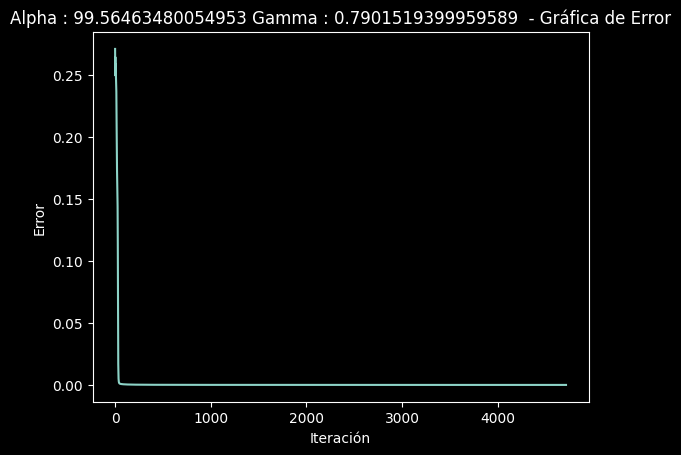

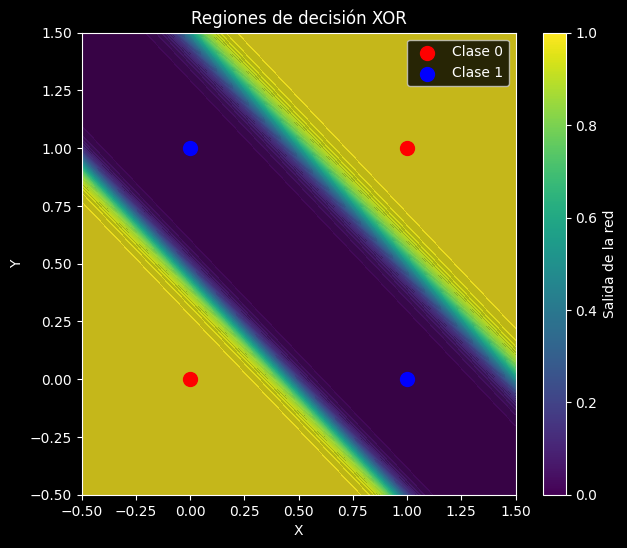

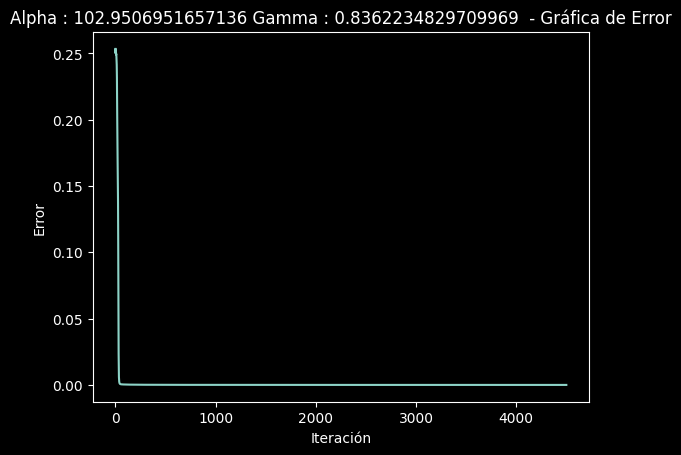

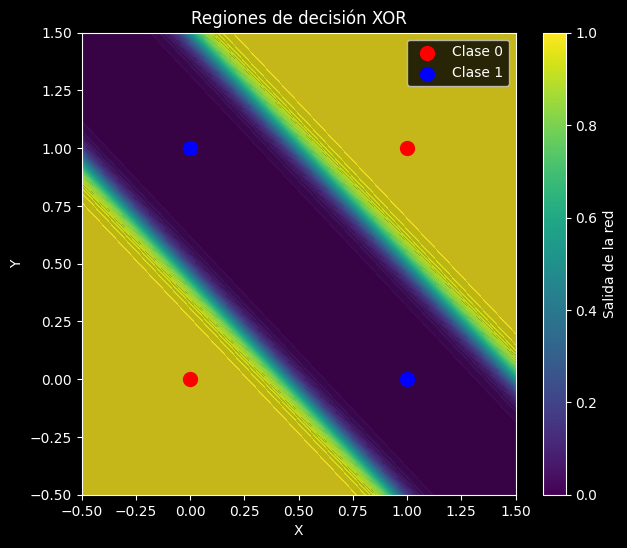

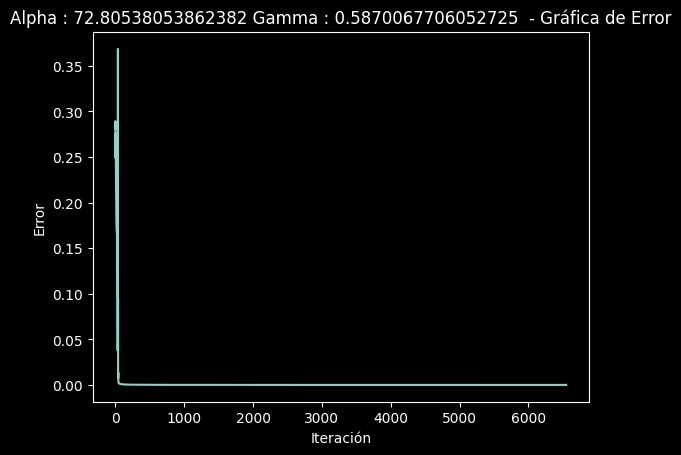

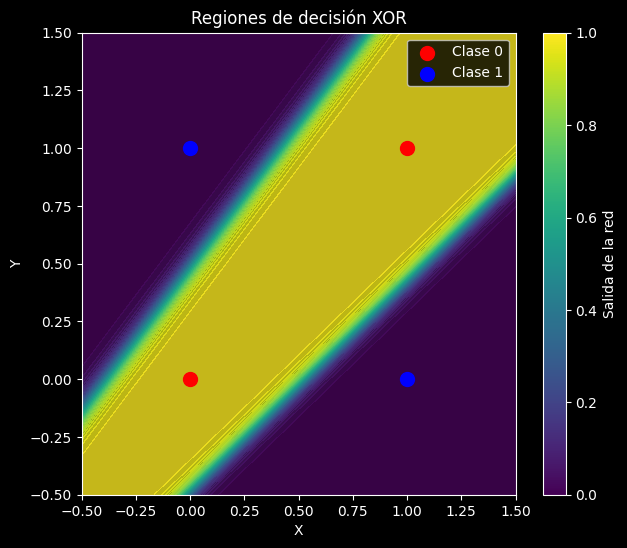

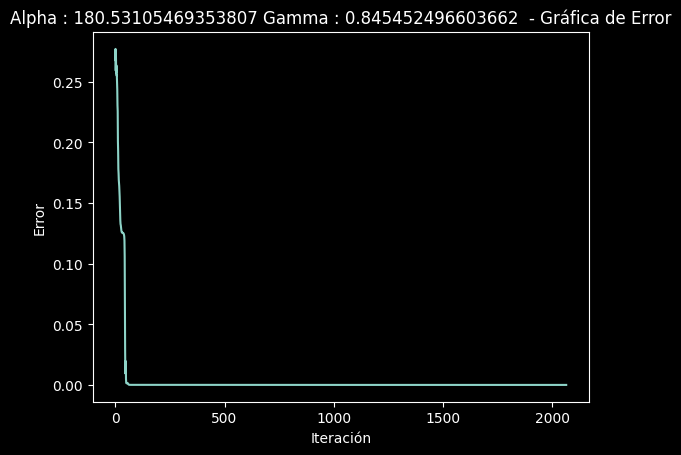

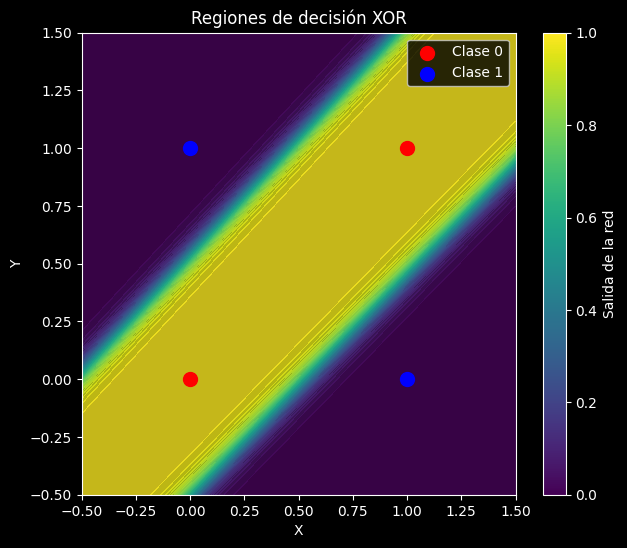

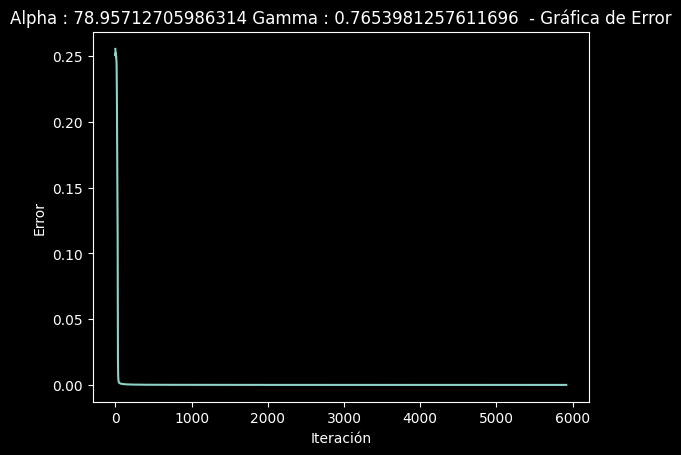

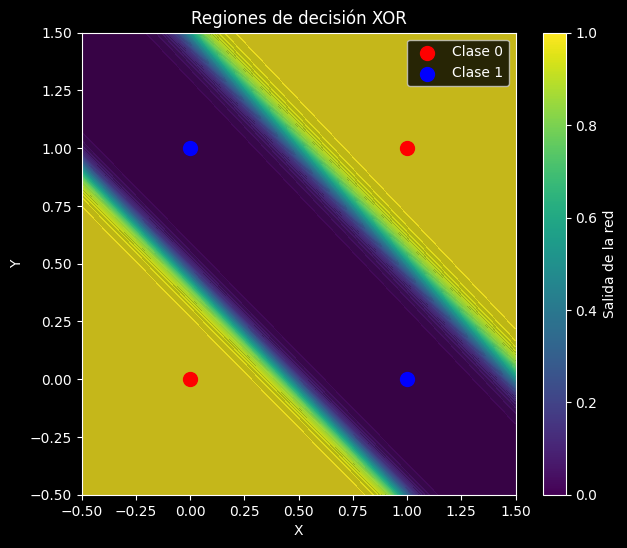

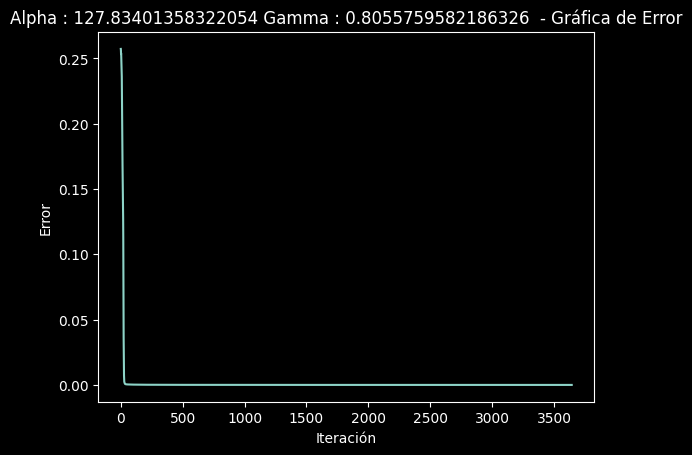

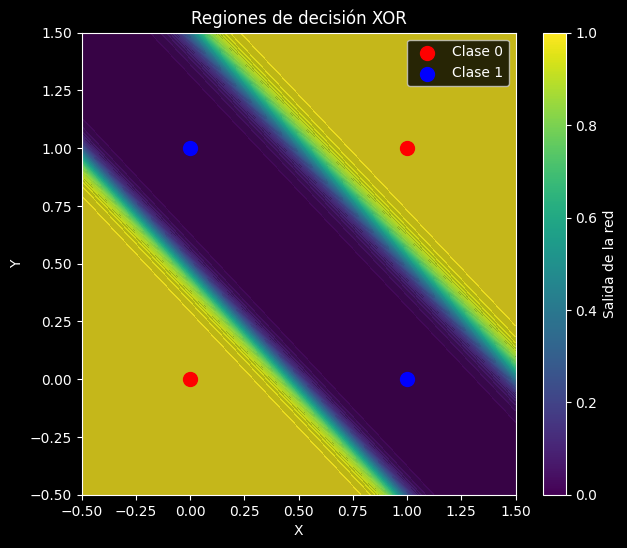

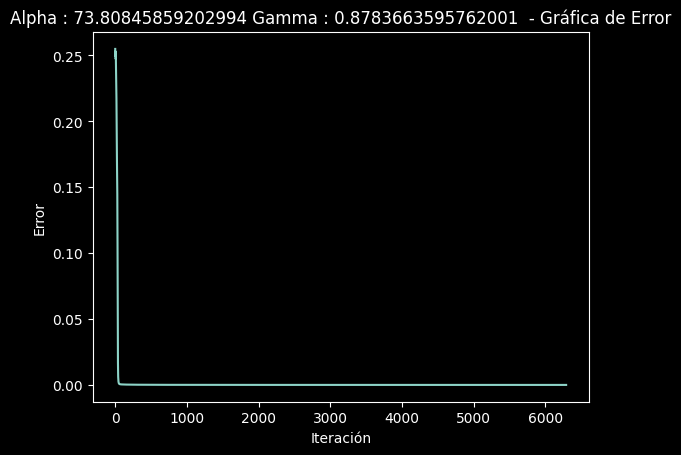

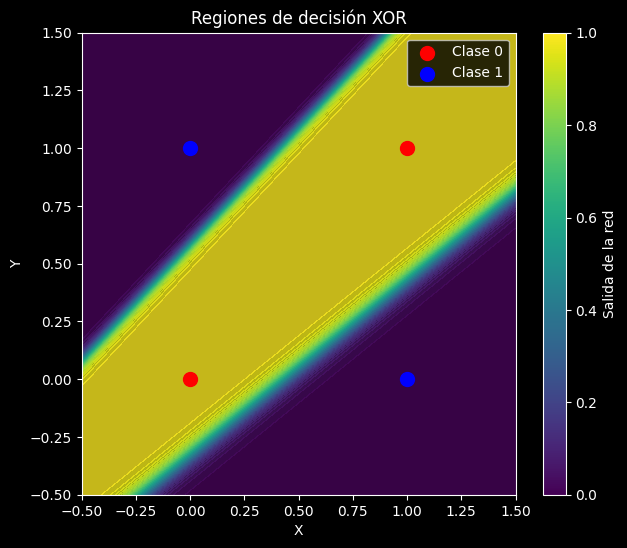

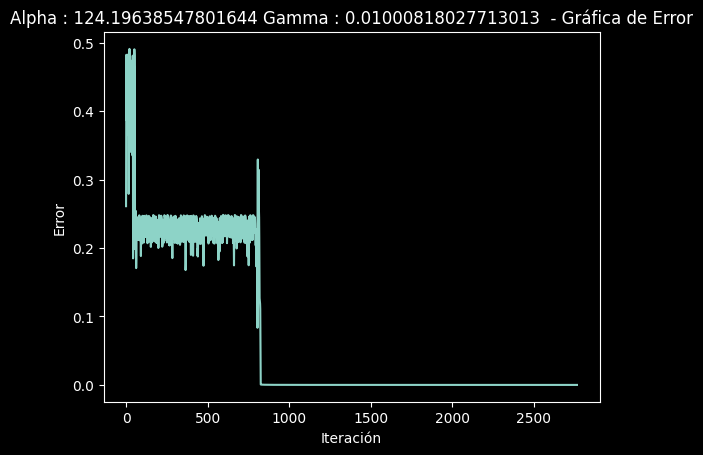

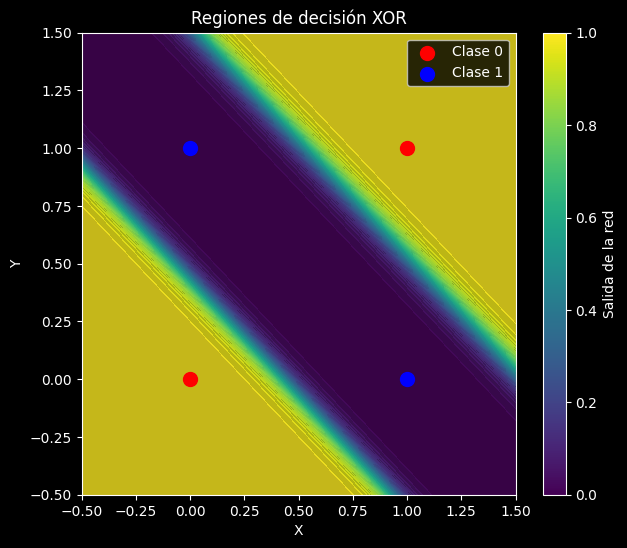

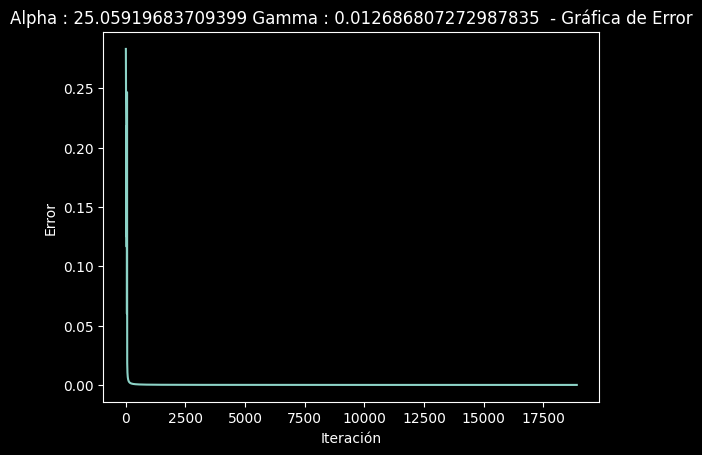

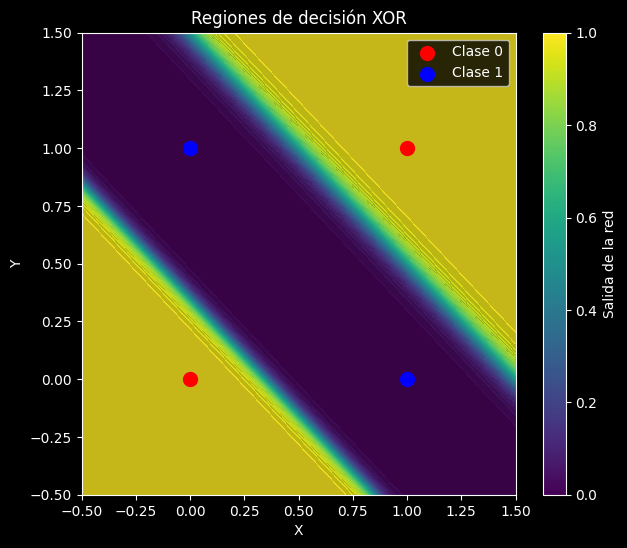

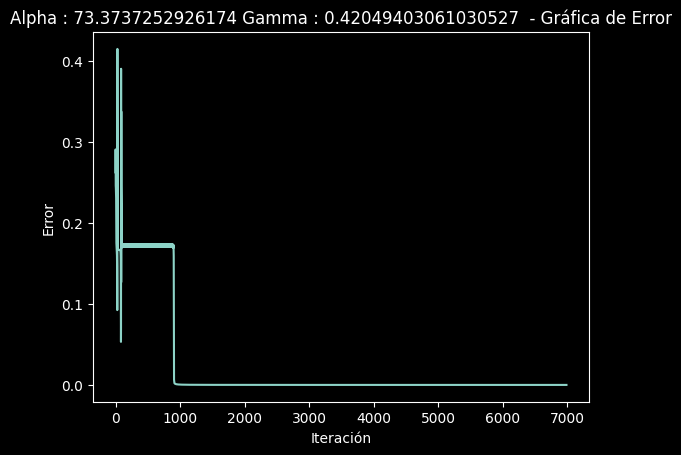

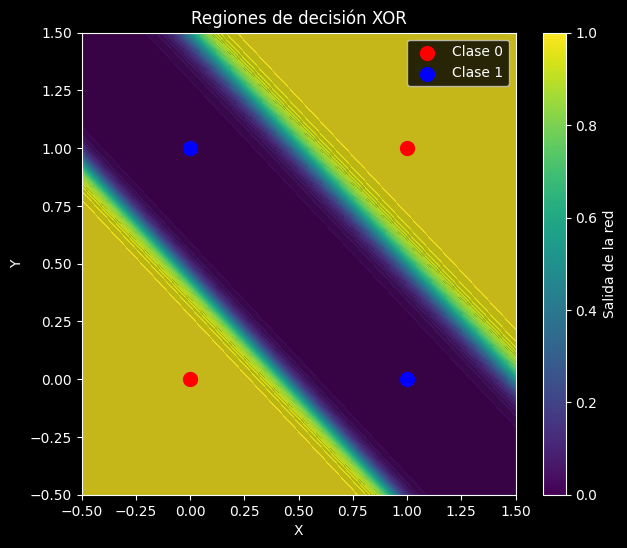

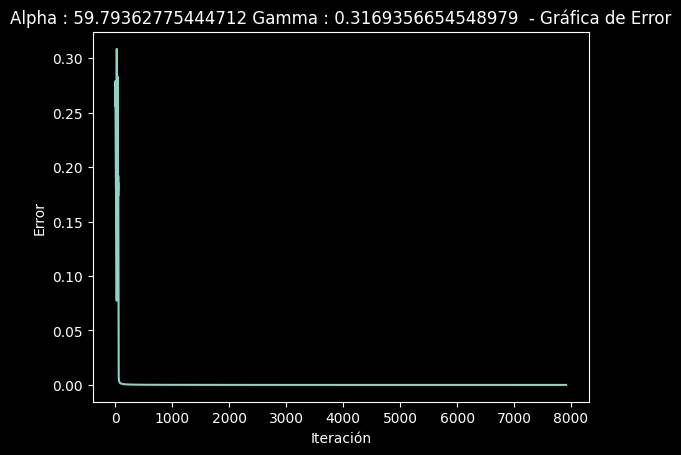

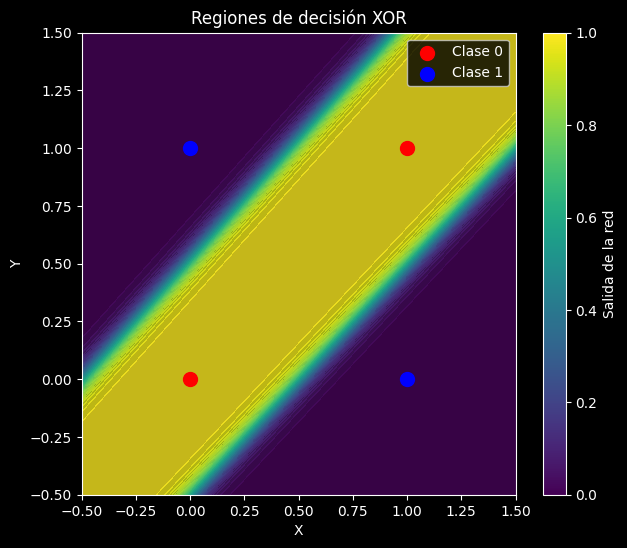

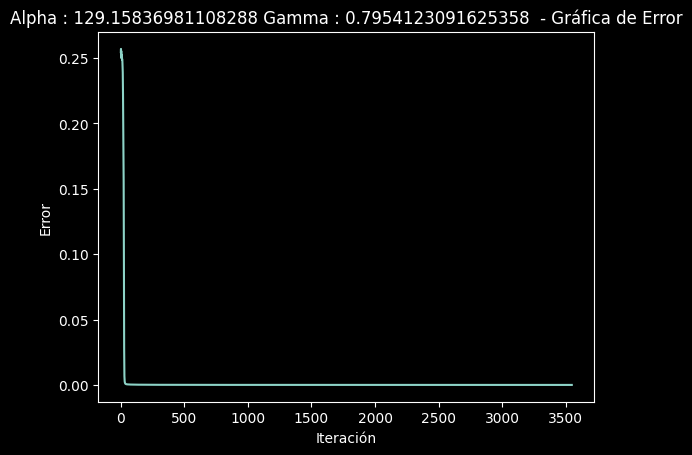

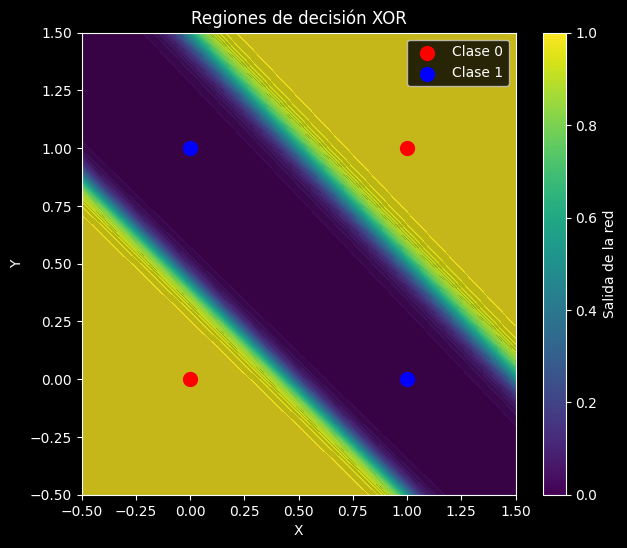

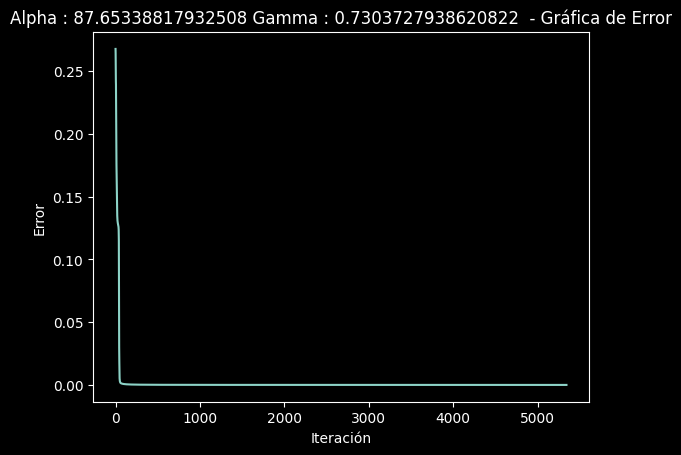

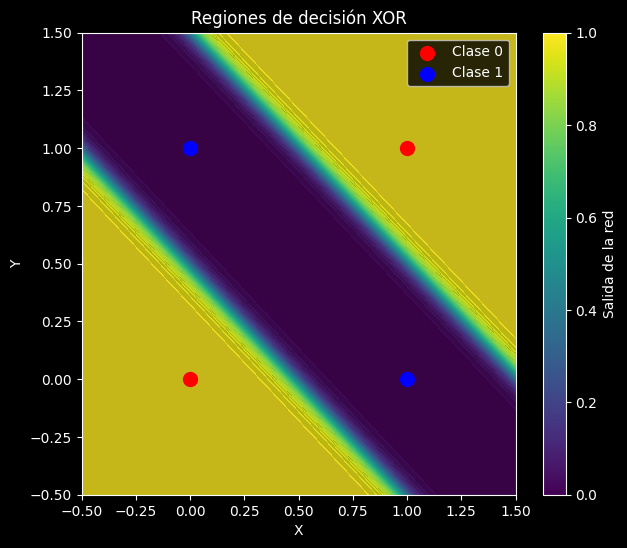

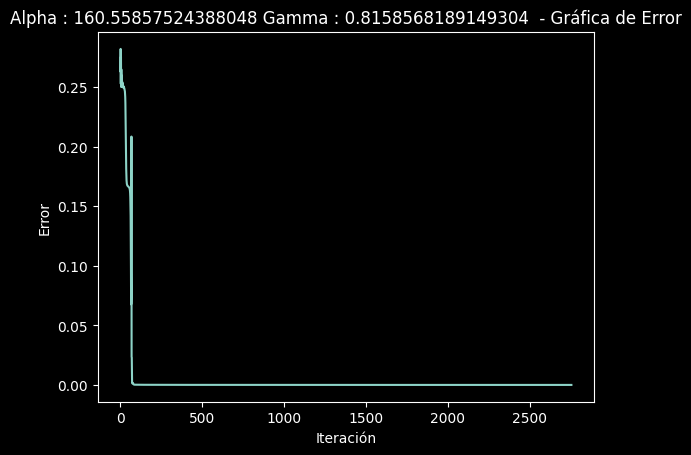

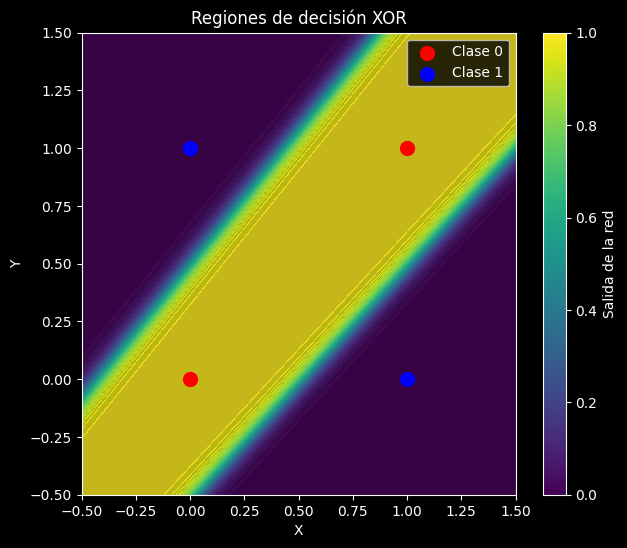

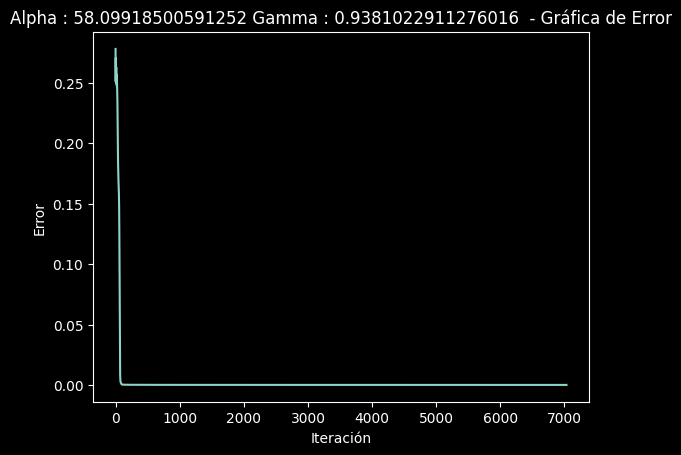

   Intento       Alpha     Gamma    Value Precisión  Error
0       13    40.36218  0.928639  0.00001        77  11489
1       14   45.818542  0.848369  0.00001       137  10270
2       16    46.88344  0.942506  0.00001        42   9176
3       17  176.510234    0.8683  0.00001        28   1621
4       19  105.840223  0.825866  0.00001       174   4515
5       20  108.614445  0.812287  0.00001        27   4238
6       21   99.564635  0.790152  0.00001        29   4713
7       22  102.950695  0.836223  0.00001        29   4500
8       24   72.805381  0.587007  0.00001        31   6547
9       25  180.531055  0.845452  0.00001        42   2063
10      27   78.957127  0.765398  0.00001        30   5915
11      31  127.834014  0.805576  0.00001        20   3642
12      33   73.808459  0.878366  0.00001        32   6290
13      34  124.196385  0.010008  0.00001       806   2764
14      35   25.059197  0.012687  0.00001        24  18909
15      37   73.373725  0.420494  0.00001        27   69

In [22]:
XOR_EPSILON = 0.00001
XOR_MAX_EPOCHS = 20000

def objective_xor(trial, epsilon : float = XOR_EPSILON):
    alpha = trial.suggest_float("alpha", 1, 200, log=True)
    gamma = trial.suggest_float("gamma", 0, 0.95, log=False)
    mp = MultilayerPerceptron([DataXOR.X.shape[1], DataXOR.M, DataXOR.T.shape[1]], alpha, gamma, 1000)
    history_error, history_accuracy = mp.train_mlp(XOR_MAX_EPOCHS, DataXOR.X, DataXOR.T, epsilon=epsilon)

    if history_error[-1] < epsilon:
        accuracy = torch.tensor(history_accuracy)
        error = torch.tensor(history_error)

        visualization.make_decision_boundary_plot(mp.Wo, mp.Ws, mp.Bo, mp.Bs ,-0.5, 1.5,-0.5, 1.5, DataXOR.class0, DataXOR.class1)
        visualization.make_error_plot(history_error, f"Alpha : {alpha} Gamma : {gamma} ")

        trial.set_user_attr("accuracy", torch.where(accuracy > 0.99)[0][0].item())
        trial.set_user_attr("error", torch.where(error < epsilon)[0][0].item())

    return history_error[-1]


def study_xor(objective):
    optuna.logging.set_verbosity(optuna.logging.ERROR)

    stud = optuna.create_study(direction="minimize")
    stud.optimize(objective, n_trials=50)

    optuna.visualization.plot_optimization_history(stud).show()
    optuna.visualization.plot_rank(stud).show()
    optuna.visualization.plot_param_importances(stud).show()
    return stud.trials

def show_best_trial(trials, epsilon : float = XOR_EPSILON):
    table = Table(pd.DataFrame(), ["Intento","Alpha", "Gamma", "Value", "Precisión","Error"], "Optimizacion")

    for t in trials:
        if t.value < epsilon:

            ind = table.obtain_row_count()

            table.add(ind, "Intento", t.number)
            table.add(ind, "Alpha", t.params["alpha"])
            table.add(ind, "Gamma", t.params["gamma"])
            table.add(ind, "Value", t.value)

            table.add(ind, "Precisión", t.user_attrs["accuracy"])
            table.add(ind, "Error", t.user_attrs["error"])

    table.show()
    table.latex()

show_best_trial(study_xor(objective_xor))

10000


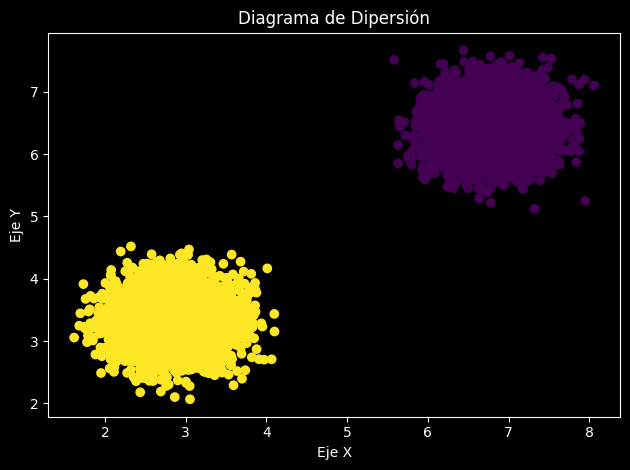

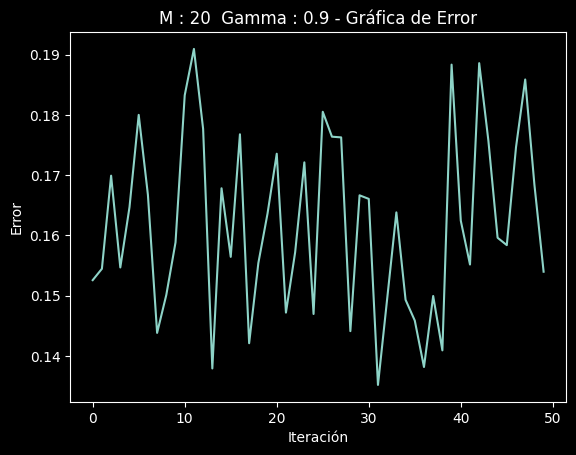

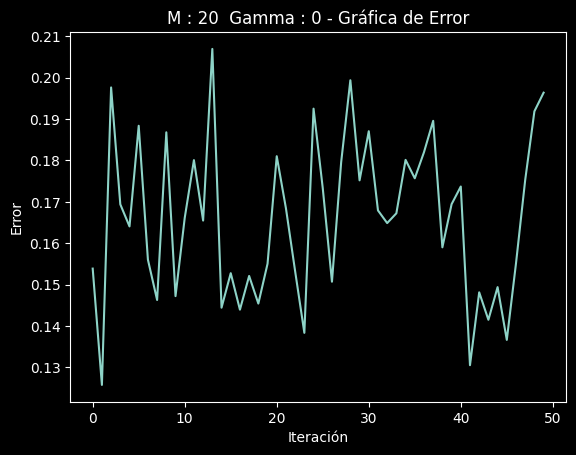

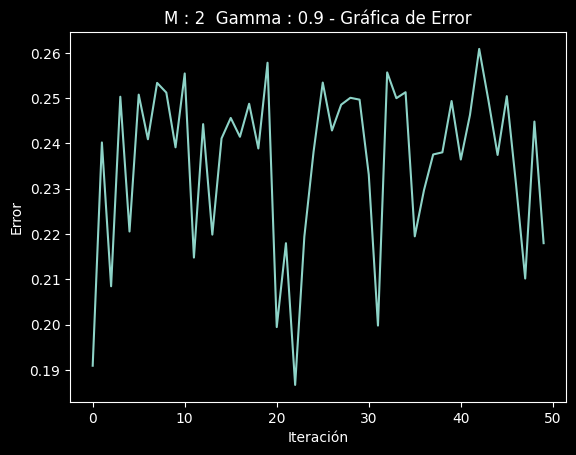

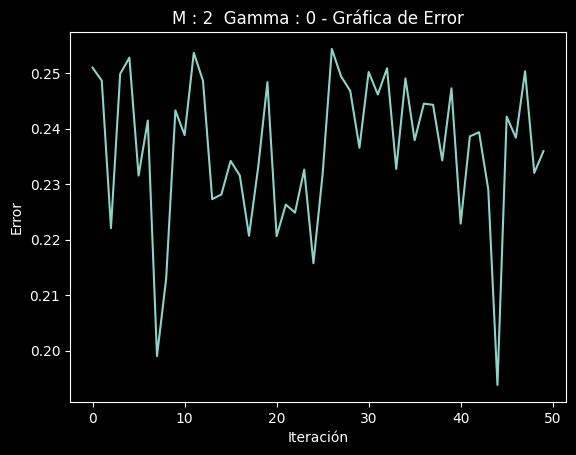

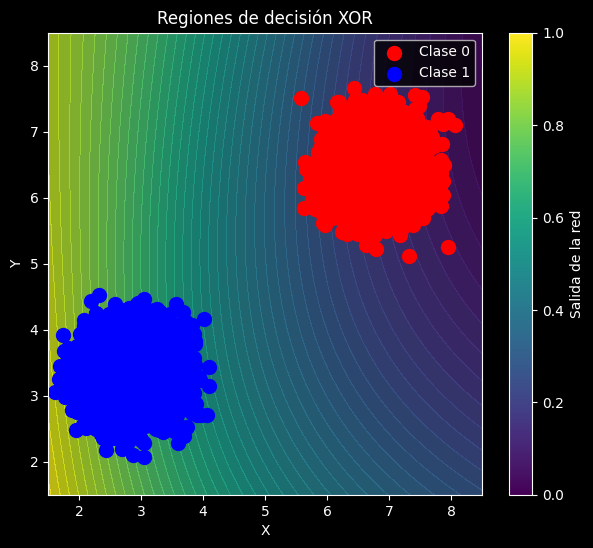

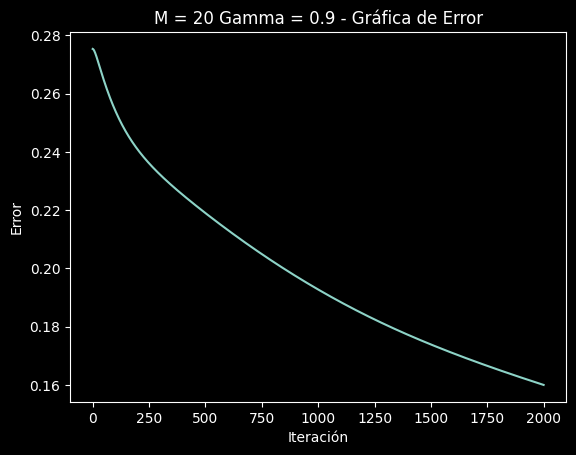

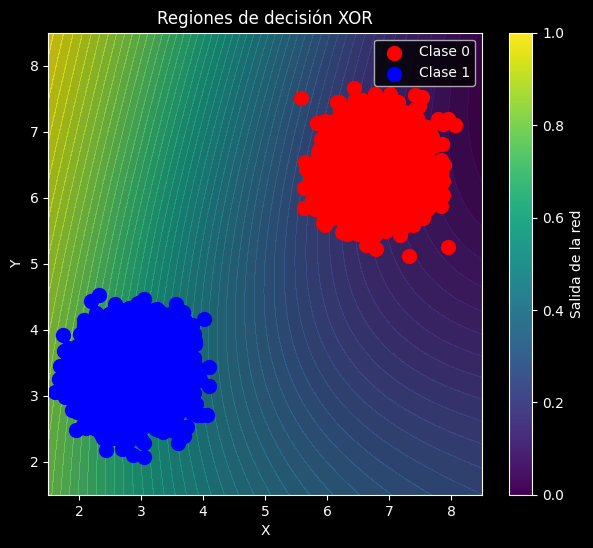

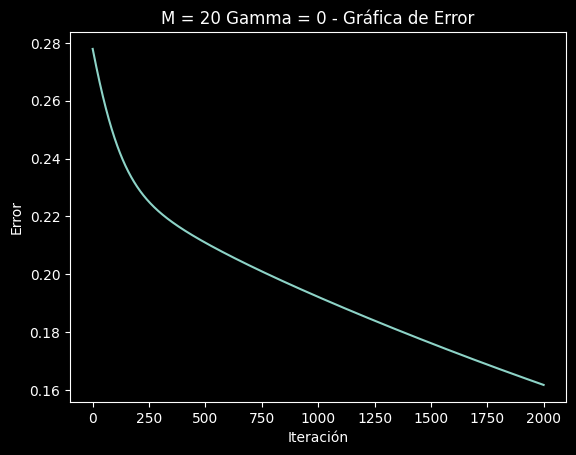

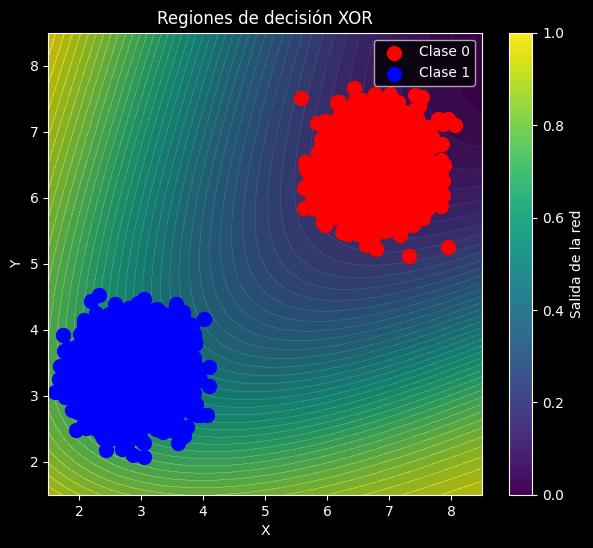

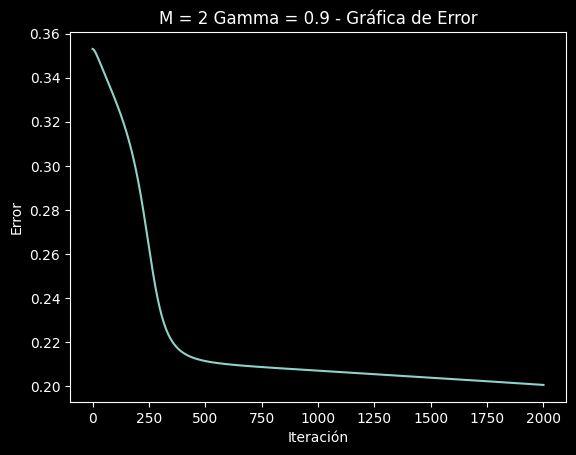

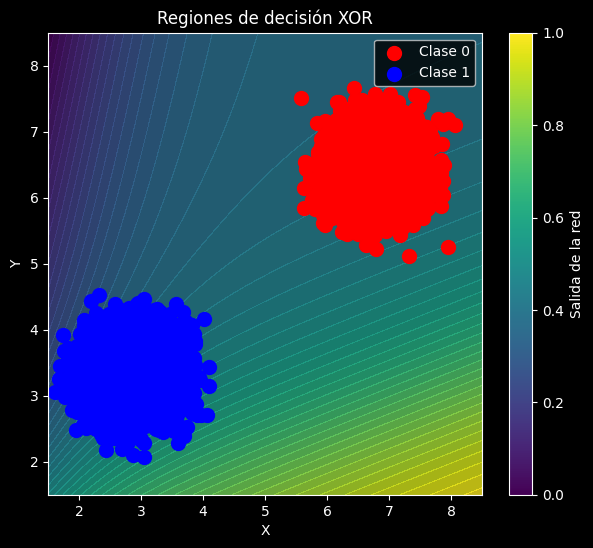

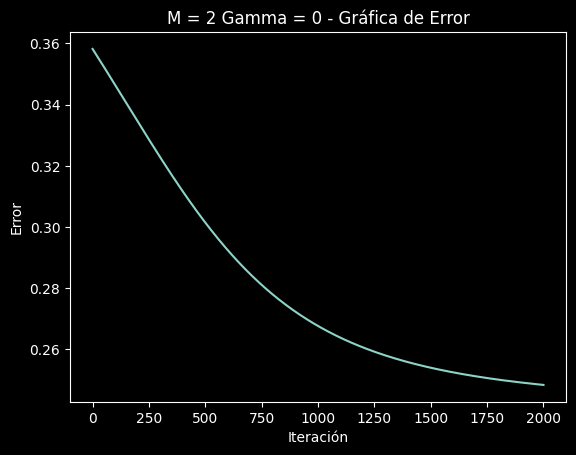

10000


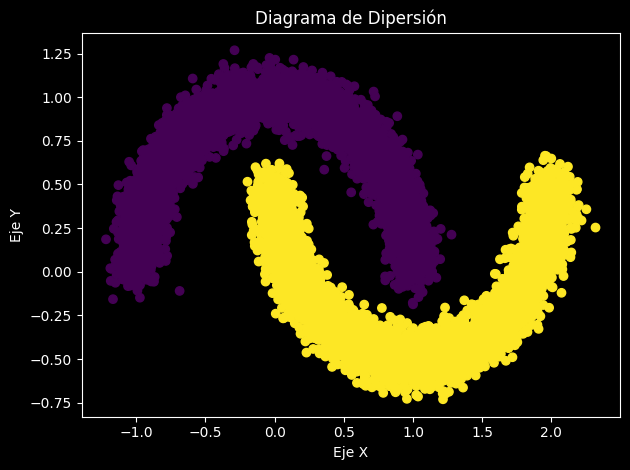

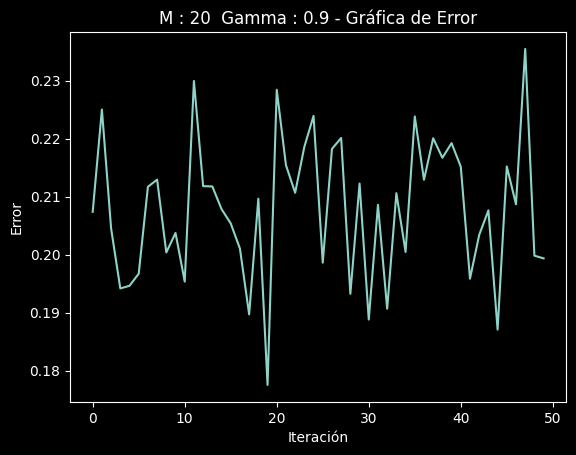

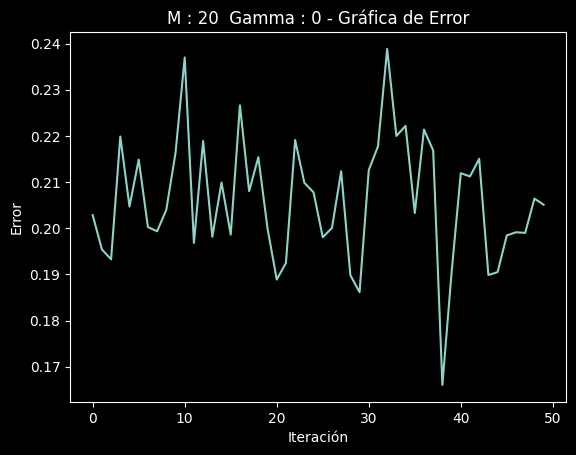

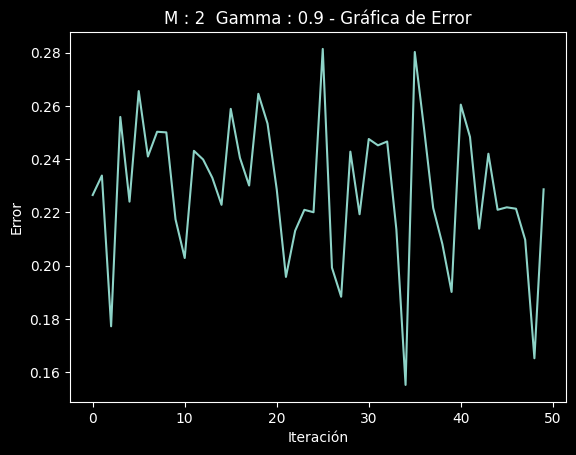

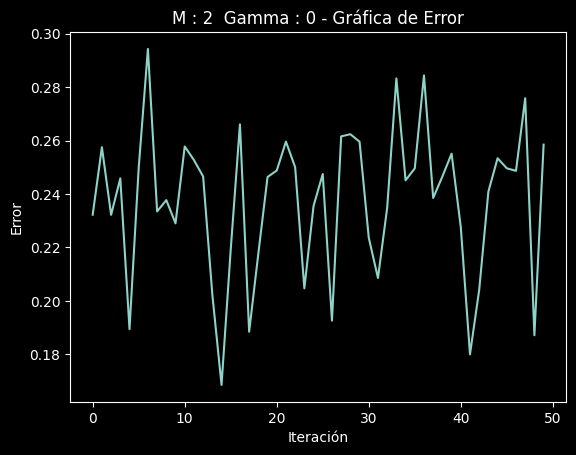

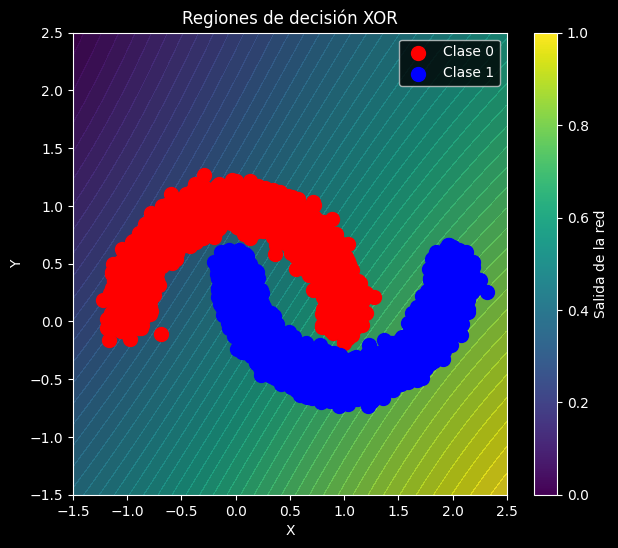

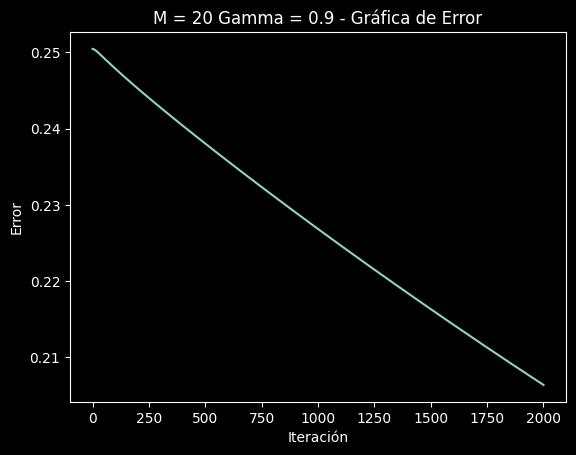

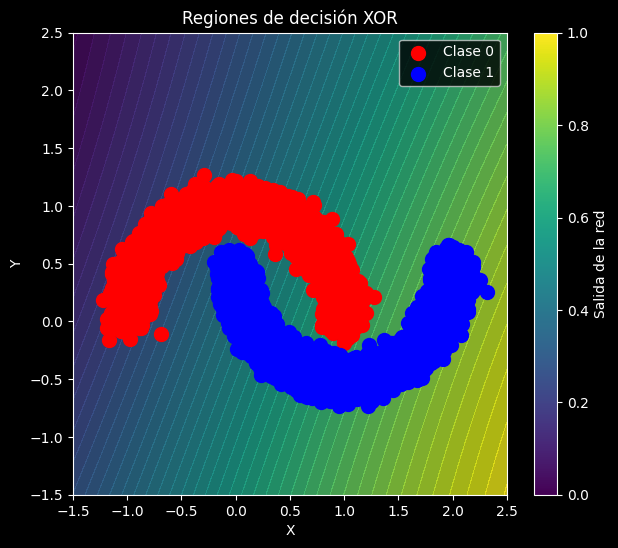

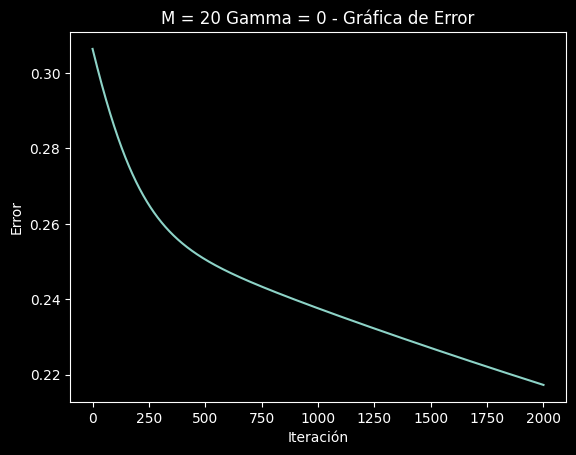

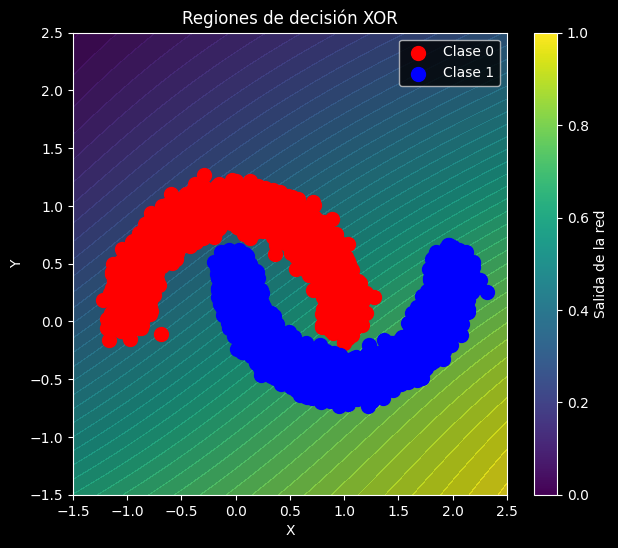

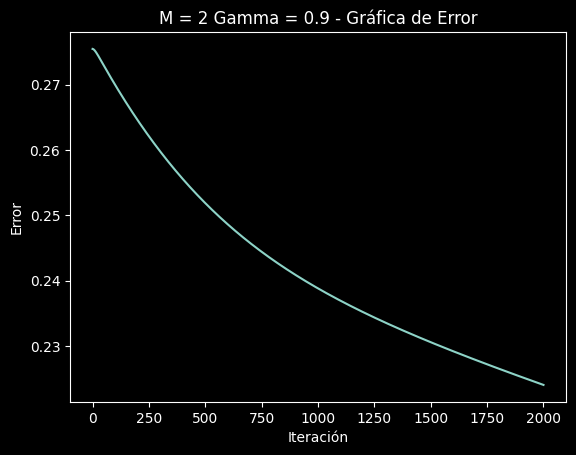

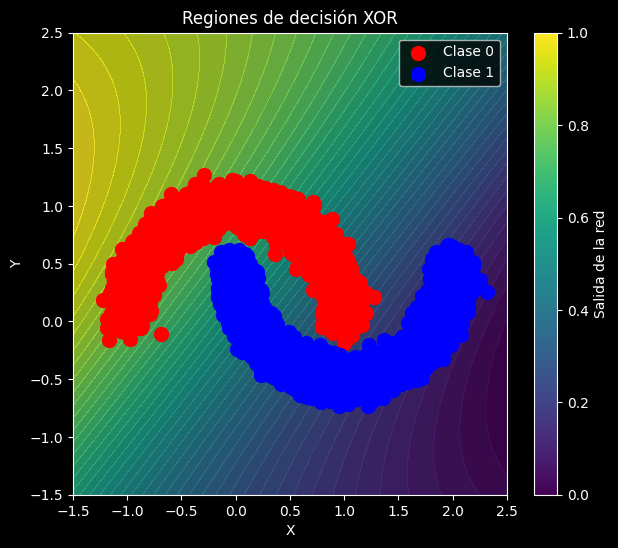

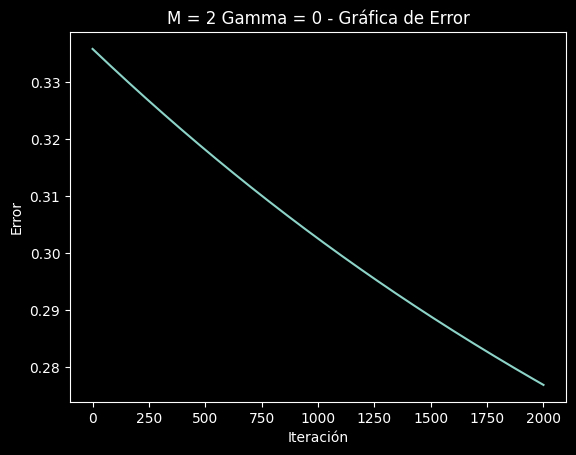

In [98]:
class Analyze:
    def __init__(self, seed, func):
        self.data, self.labels = func(seed)
        print(self.data.shape[0])
        visualization.make_scatter(self.data[:,0], self.data[:, 1], self.labels)

        self.config = [[20, 0.9], [20, 0], [2, 0.9], [2, 0]]

        self.class0 = self.data[self.labels == 0]
        self.class1 = self.data[self.labels == 1]

    def run_50_iterations(self, min_x : float, max_x : float, min_y : float, max_y : float):

        test_error = [[] for _ in range(len(self.config))]

        for i in range(50):
            train_data, test_data = DatasetGenerator.split_data(0.2, i + 1, self.data, self.labels)

            for j, conf in enumerate(self.config):
                M, gamma = conf
                mlp = MultilayerPerceptron([2, M, 1], 0.01, gamma, 1e3)
                _ , _ = mlp.train_mlp(2000, train_data[0], train_data[1].view(-1,1))

                mlp.forward(test_data[0])
                test_error[j].append(mlp.get_error(test_data[1].view(-1,1)).item())

        for i in range(4):
            visualization.make_error_plot(test_error[i], f"M : {self.config[i][0]}  Gamma : {self.config[i][1]}")

    def run_single(self, min_x : float, max_x : float, min_y : float, max_y : float):

        train_data, test_data = DatasetGenerator.split_data(0.2, 0, self.data, self.labels)

        for M, gamma in self.config:
            mlp = MultilayerPerceptron([2, M, 1], 0.01, gamma, 1e6)
            history_error, _ = mlp.train_mlp(2000, train_data[0], train_data[1].view(-1,1))

            visualization.make_decision_boundary_plot(mlp.Wo, mlp.Ws, mlp.Bo, mlp.Bs, min_x, max_x, min_y, max_y, self.class0, self.class1)
            visualization.make_error_plot(history_error, f"M = {M} Gamma = {gamma}")


separable_analyze = Analyze(444,DatasetGenerator.generate_linearly_separable)
separable_analyze.run_50_iterations(1.5, 8.5, 1.5, 8.5)
separable_analyze.run_single(1.5, 8.5, 1.5, 8.5)

nonseparable_analyze = Analyze(777,DatasetGenerator.generate_nonlinearly_separable)
nonseparable_analyze.run_50_iterations(-1.5, 2.5, -1.5, 2.5)
nonseparable_analyze.run_single(-1.5, 2.5, -1.5, 2.5)

# AlexNet

In [ ]:
ACRIMA_EPSILON = 1e-10

class ImageNormalizerMLP:
    def __call__(self, img):
        X = torch.from_numpy(np.array(img)).float()
        X_norm = X / (X.max() + ACRIMA_EPSILON)
        return X_norm.flatten()

class ImageNormalizerAlex:
    def __call__(self, img):
        X = torch.from_numpy(np.array(img)).float()
        X_norm = X / (X.max() + ACRIMA_EPSILON)
        return X_norm.permute(2,0,1).contiguous()

class Dataset:
    def __init__(self, d: int, train_batch: int, test_batch: int, seed: int, image_normalizer, train_size : float = 0.8):
        self.d = d*d*3
        trans = transforms.Compose([
            transforms.Resize((d,d)),
            image_normalizer(),
        ])

        self.dataset = ImageFolder (
            "dataset",
            transform = trans
        )

        train_dataset, test_dataset = random_split(
            self.dataset,
            [train_size, 1 - train_size],
            generator = torch.Generator().manual_seed(seed)
        )

        self.train_loader = DataLoader(
            train_dataset,
            batch_size=train_batch,
            shuffle = False,
            num_workers=0,
            pin_memory=(DEVICE == "cuda")
        )

        self.test_loader = DataLoader(
            test_dataset,
            batch_size=test_batch,
            shuffle=False,
            num_workers=0,
            pin_memory=(DEVICE == "cuda")
        )

        print(f"Dataset loaded with d={self.d}, train_batches={len(self.train_loader)}x{self.train_loader.batch_size} and test_batches={len(self.test_loader)}x{self.test_loader.batch_size}")

#dataset = Dataset(224,30,30,0,ImageNormalizerAlex)

In [ ]:
def test_normalizer_rango_0_1():
    """La salida ℓ∞ debe quedar en [0, 1]."""
    norm = ImageNormalizerMLP()
    img = Image.fromarray((np.random.rand(16, 16, 3) * 255).astype(np.uint8))
    out = norm(img)
    assert out.min().item() >= 0.0
    assert out.max().item() <= 1.0
    print("OK rango [0,1]:", out.min().item(), out.max().item())

# test_normalizer_rango_0_1()

def test_normalizer_max_es_1():
    """Dividir por el máximo => el píxel máximo de la imagen pasa a valer 1."""
    norm = ImageNormalizerMLP()
    arr = np.zeros((8, 8, 3), dtype=np.uint8)
    arr[0, 0] = 200          # un solo píxel con el valor máximo
    out = norm(Image.fromarray(arr))
    assert torch.isclose(out.max(), torch.tensor(1.0), atol=1e-6)
    print("OK max==1:", out.max().item())

# test_normalizer_max_es_1()

In [ ]:
@dataclass
class ACRIMA:
    configs = [
          32,   # D = 32*32*3 = 3072
          48,   # D = 48*48*3 = 6912
          64,   # D = 64*64*3 = 12288
    ]
    total = 400

In [ ]:
def study_acrima(dataset: Dataset):
    d = round(math.sqrt(dataset.d))
    def objective(trial):
        alpha = trial.suggest_float("alpha", 1e-3, 5, log=True)
        gamma = trial.suggest_float("gamma", 1e-6, 1, log=False)
        M = trial.suggest_int("M", d, ACRIMA.total, log=True) # 2*d + 1 como lim sup, no funciona bien
        mlp = MultilayerPerceptron([dataset.d, M, 1], alpha, gamma, 1000)
        history_error = mlp.train_batches(50, dataset.train_loader, alpha, gamma)
        return history_error[-1]

    optuna.logging.set_verbosity(optuna.logging.ERROR)

    stud = optuna.create_study(direction="minimize")
    stud.optimize(objective, n_trials=50)

    optuna.visualization.plot_optimization_history(stud).show()
    optuna.visualization.plot_rank(stud).show()
    optuna.visualization.plot_param_importances(stud).show()
    optuna.visualization.plot_parallel_coordinate(stud).show()

    return stud.best_params["alpha"], stud.best_params["gamma"], stud.best_params["M"]

def obtain_best_parameters_acrima():
    for pix in ACRIMA.configs:
        data = Dataset(pix,64,70,1, ImageNormalizerMLP, 0.5)
        alpha, gamma, m = study_acrima(data)
        data = Dataset(pix,64,70,2, ImageNormalizerMLP)
        mlp = MultilayerPerceptron([data.d, m, 1], alpha, gamma, 1000)
        history_error = mlp.train_batches(100, data.train_loader, alpha, gamma)
        visualization.make_error_plot(history_error, f"M = {m} Gamma = {gamma} Alpha = {alpha}")
        print(f"M = {m} Gamma = {gamma} Alpha = {alpha} D = {pix}")
        print(mlp.evaluate_batches(data.test_loader))

# obtain_best_parameters_acrima()

# AlexNet

## Train / Test

In [ ]:
class Alex:
    def __init__(self, criterion, activation, alpha : float , gamma : float):
        self.model = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
        num_ftrs = self.model.classifier[6].in_features
        self.model.classifier[6] = nn.Linear(num_ftrs, 1)
        self.model.to(DEVICE)

        self.criterion = criterion()
        self.optimizer = optim.SGD(self.model.parameters(), lr = alpha, momentum = gamma)
        self.activation = activation()

    def train(self, train_loader, epoch : int):
        self.model.train()
        running_loss = 0.0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(DEVICE), target.to(DEVICE).float().view(-1,1)
            self.optimizer.zero_grad()
            output = self.activation(self.model(data))
            loss = self.criterion(output, target)
            loss.backward()
            self.optimizer.step()
            running_loss += loss.item()
            # if batch_idx % 100 == 0:
                # print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} ({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')
        avg_loss = running_loss / len(train_loader)
        # print(f'====> Epoch: {epoch} Average loss: {avg_loss:.4f}')
        return avg_loss

    def test(self, test_loader):
        self.model.eval()
        test_loss = 0
        correct = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(DEVICE), target.to(DEVICE).float().view(-1,1)
                output = self.activation(self.model(data))
                test_loss += self.criterion(output, target).item() # Sum up batch loss
                pred = (output >= 0.5).float()
                correct += pred.eq(target).sum().item()

        test_loss /= len(test_loader)

        # print(f'\nTest set: Average loss: {test_loss}, Accuracy: {correct}/{len(test_loader.dataset)} ({100. * correct / len(test_loader.dataset)}%)\n')
        return test_loss, 100. * correct / len(test_loader.dataset)

In [ ]:
def training(num_epochs : int, dataset : Dataset, alpha : float = 0.001, gamma : float = 0.9):
    train_losses = []
    test_losses = []
    test_accuracies = []

    alex = Alex(nn.MSELoss,nn.Sigmoid,alpha,gamma)

    for epoch in range(1, num_epochs + 1):
        train_loss = alex.train(dataset.train_loader, epoch)
        test_loss, test_accuracy = alex.test(dataset.test_loader)
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)

    return train_losses, test_losses[-1], test_accuracies[-1]

#training(30, Dataset(224,64,70,1, ImageNormalizerAlex, 0.8), 0.013869337970587613, 0.5930316478036102)

In [ ]:
def study_alex_acrima(dataset: Dataset):
    def objective(trial):
        alpha = trial.suggest_float("alpha", 1e-5, 10, log=True)
        gamma = trial.suggest_float("gamma", 1e-5, 1, log=False)
        train_error, _, _ = training(50, dataset, alpha, gamma)
        return train_error[-1]

    optuna.logging.set_verbosity(optuna.logging.INFO)

    stud = optuna.create_study(direction="minimize")
    stud.optimize(objective, n_trials=50)

    optuna.visualization.plot_optimization_history(stud).show()
    optuna.visualization.plot_rank(stud).show()
    optuna.visualization.plot_param_importances(stud).show()
    optuna.visualization.plot_parallel_coordinate(stud).show()

    return stud.best_params["alpha"], stud.best_params["gamma"]
# study_alex_acrima(Dataset(224,64,70,1, ImageNormalizerAlex, 0.5))

In [ ]:
def run_many(param_mlp, param_alex):

    table = Table(pd.DataFrame(),["Iteración","MLP","Alex"],"Comparacion_Final")
    TRAIN_BITCH, TEST_BATCH = 128, 70

    for i in range(1):
        data_mlp = Dataset(param_mlp['d'],TRAIN_BITCH, TEST_BATCH, i, ImageNormalizerMLP)
        data_alex = Dataset(224, TRAIN_BITCH, TEST_BATCH, i, ImageNormalizerAlex)

        ind = table.obtain_row_count()

        table.add(ind,"Iteración", f"{i}")

        mlp = MultilayerPerceptron([data_mlp.d,param_mlp['m'],1], param_mlp['alpha'], param_mlp['gamma'], 1e4)
        mlp_error = mlp.train_batches(50, data_mlp.train_loader)
        error, accuracy = mlp.evaluate_batches(data_mlp.test_loader)

        table.add(ind, "MLP", f"{error},{accuracy}")

        alex_error, error, accuracy = training(50, data_alex, param_alex['alpha'], param_alex['gamma'])
        table.add(ind, "Alex", f"{error},{accuracy}")

        if i%4 == 0:
            visualization.make_error_plot(mlp_error, f"Entrenamiento MLP Corrida {i+1}")
            visualization.make_error_plot(alex_error, f"Entrenamiento Alex Corrida {i+1}")

    table.show()
    table.latex(False)

run_many({
    'm': 399,
    'd' : 128,
    'alpha' : 0.349110755106244,
    'gamma' : 0.9562842390224487
},
{
    'alpha': 0.013869337970587613,
    'gamma': 0.5930316478036102
})